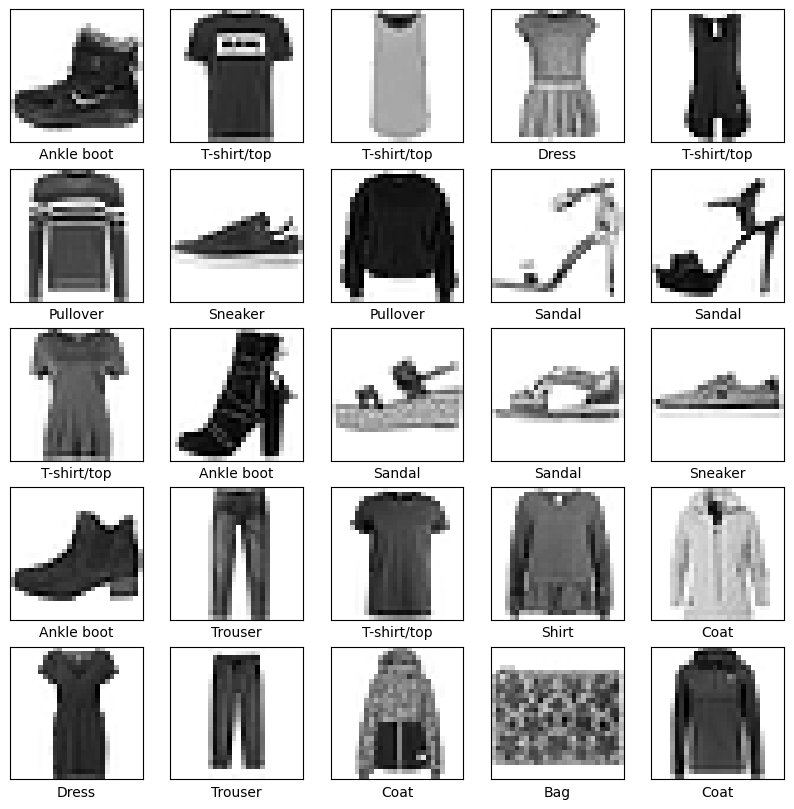

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

# The labels are integers (0-9). Let's map them to their class names.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [9]:
# Normalize the training and test image data
x_train_normalized = x_train / 255.0
x_test_normalized = x_test / 255.0

# Reshape the data for the CNN model
# The shape should be (number_of_images, height, width, channels)
x_train_reshaped = x_train_normalized.reshape(x_train_normalized.shape[0], 28, 28, 1)
x_test_reshaped = x_test_normalized.reshape(x_test_normalized.shape[0], 28, 28, 1)

# Verify the new shape
print("Shape of reshaped x_train:", x_train_reshaped.shape)
print("Shape of reshaped x_test:", x_test_reshaped.shape)

Shape of reshaped x_train: (60000, 28, 28, 1)
Shape of reshaped x_test: (10000, 28, 28, 1)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten and Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Add a dropout layer to prevent overfitting
    Dense(10, activation='softmax') # Output layer for 10 classes
])

# Print a summary of the model's architecture
model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train the model
history = model.fit(
    x_train_reshaped, 
    y_train, 
    epochs=10, 
    validation_data=(x_test_reshaped, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7990 - loss: 0.5532 - val_accuracy: 0.8625 - val_loss: 0.3715
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8662 - loss: 0.3714 - val_accuracy: 0.8819 - val_loss: 0.3204
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8829 - loss: 0.3248 - val_accuracy: 0.8934 - val_loss: 0.2913
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8947 - loss: 0.2935 - val_accuracy: 0.8987 - val_loss: 0.2728
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9000 - loss: 0.2725 - val_accuracy: 0.8985 - val_loss: 0.2760
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9074 - loss: 0.2525 - val_accuracy: 0.9063 - val_loss: 0.2549
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9134 - loss: 0.2376 - val_accuracy: 0.9043 - val_loss: 0.2559
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9159 - loss: 0.2242 - 

In [13]:
# Evaluate the model's performance on the test data
test_loss, test_acc = model.evaluate(x_test_reshaped, y_test, verbose=2)

print(f"\nTest accuracy: {test_acc:.4f}")

313/313 - 0s - 946us/step - accuracy: 0.9084 - loss: 0.2562

Test accuracy: 0.9084


In [18]:
import numpy as np

# Make predictions
predictions = model.predict(x_test_reshaped)

# Get the predicted class for the first 5 images
predicted_classes = np.argmax(predictions, axis=1)


print("Predicted classes for the first 5 test images:")
for n in predicted_classes[:5]:
    print(class_names[n])

print("\nActual labels for the first 5 test images:")
for n in y_test[:5]:
    print(class_names[n])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step
Predicted classes for the first 5 test images:
Ankle boot
Pullover
Trouser
Trouser
Shirt

Actual labels for the first 5 test images:
Ankle boot
Pullover
Trouser
Trouser
Shirt


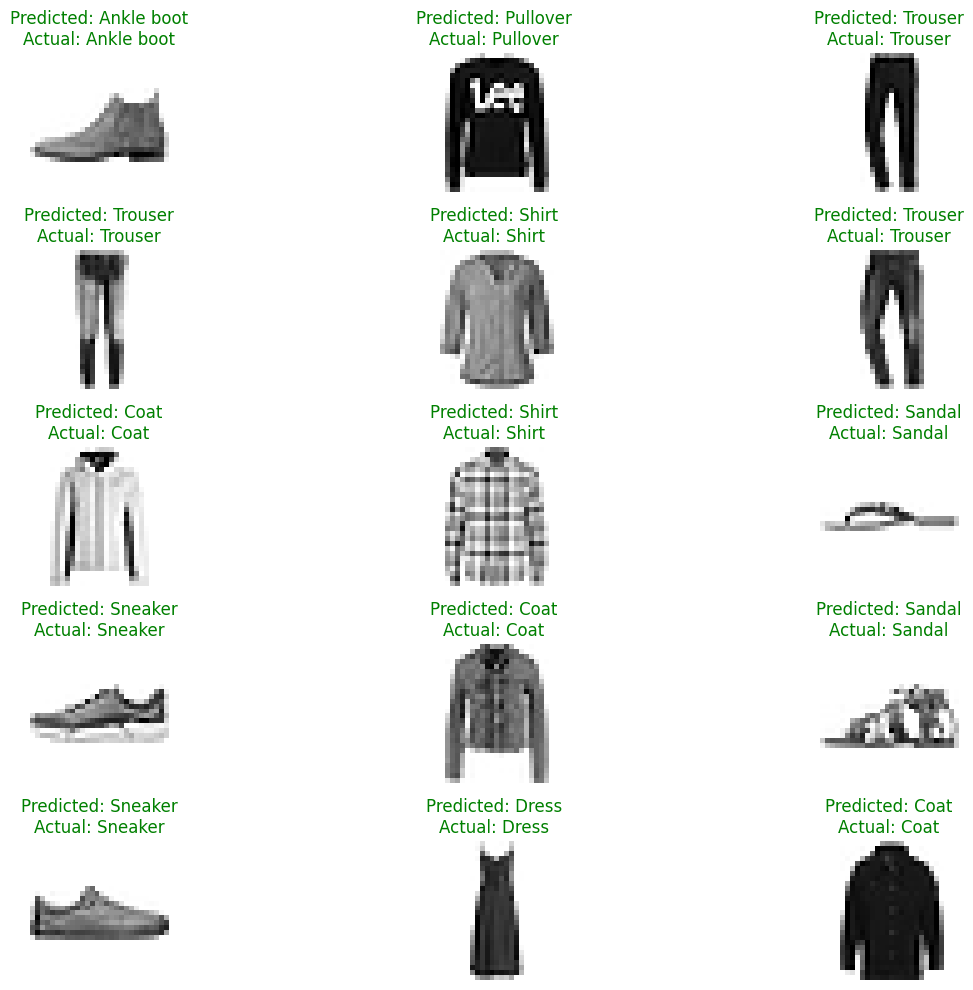

In [19]:
# Plot the first few images, their predicted labels, and their true labels
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plt.imshow(x_test_reshaped[i], cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    true_label = y_test[i]
    pred_label = np.argmax(predictions[i])
    
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Predicted: {class_names[pred_label]}\nActual: {class_names[true_label]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()